# Experiment 1 — When does a broadcast rollout fail where cluster seeding succeeds?

> **⚠ ALL DATA IN THIS NOTEBOOK IS SYNTHETIC.** Every organization simulated here was
> generated by rules written in `core/orggen.py`. Nothing is calibrated against any real
> rollout; results are arguments about *mechanisms*, not forecasts. See
> [`docs/limitations.md`](../docs/limitations.md) before quoting anything.

This is the headline experiment of **adoption-sim v0.1**: a complex-contagion model
(fractional thresholds + ready/willing/able gating) on a synthetic two-layer
organization, comparing five seeding strategies under one fixed budget.

- Model definition: [`docs/model.md`](../docs/model.md) · every modeling choice is logged
  with alternatives in [`docs/decisions.md`](../docs/decisions.md) (D-numbers cited throughout;
  all **PROVISIONAL** pending review).
- Scenario: [`scenarios/headline.toml`](scenarios/headline.toml), frozen by decision **D16**.
- Reproducibility: a single master seed drives everything; re-running this notebook
  top-to-bottom reproduces every figure exactly. Expected runtime: **2–5 minutes** on a
  laptop (multi-core); the heavy steps print their progress.
- Same computation, no notebook: `python experiments/run_experiment1.py`.


In [1]:
import sys, pathlib, time, json
HERE = pathlib.Path.cwd().resolve()
REPO = HERE if (HERE / "core").exists() else HERE.parent
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / "experiments"))

import numpy as np, networkx as nx, matplotlib.pyplot as plt
import core, exp1, plotting
from core import defaults, metrics
from core.orggen import generate_org
from core.scenario import org_kwargs, set_path, build_sim_params
from core.seeding import make_seeding

T0 = time.time()
SC = exp1.headline_scenario()
A, O, R = SC["agents"], SC["org"], SC["run"]
print(f"adoption-sim {core.__version__} · numpy {np.__version__} · networkx {nx.__version__} · python {sys.version.split()[0]}")
print(f"scenario '{SC['meta']['name']}': {SC['meta']['description']}")
print(f"master seed {R['master_seed']} · {R['replicates']} replicates per condition (fresh org each replicate, D14)")

adoption-sim 0.1.0 · numpy 2.4.6 · networkx 3.6.1 · python 3.13.13
scenario 'headline': Broadcast fails where cluster seeding succeeds; silos cap the spread (synthetic org, D16 regime).
master seed 20260610 · 20 replicates per condition (fresh org each replicate, D14)


## 1. The terrain: one organization, two networks

The generator (decision **D10**) builds a hierarchy — CEO, 8 departments, ~250 teams of
~8 — and **two deliberately different layers** on top of it:

- the **formal layer** (org chart): where announcements travel;
- the **informal layer** (who actually influences whom): dense inside teams, locally
  concentrated between ring-adjacent "sister teams" (**D15** — wide bridges), sparse
  across departments. `silo_strength` ∈ [0,1] controls cross-department scarcity.

Influence is weighted by **source credibility** (**D3**): close collaborator 1.0 ·
distant peer 0.6 · own manager 0.7 · central comms 0.3. Adoption travels only on the
informal layer; the org chart's job here is roles, units, and the broadcast channel.

2000 agents · 14244 informal ties · mean informal degree 14.2 (max 35) · 249 line teams


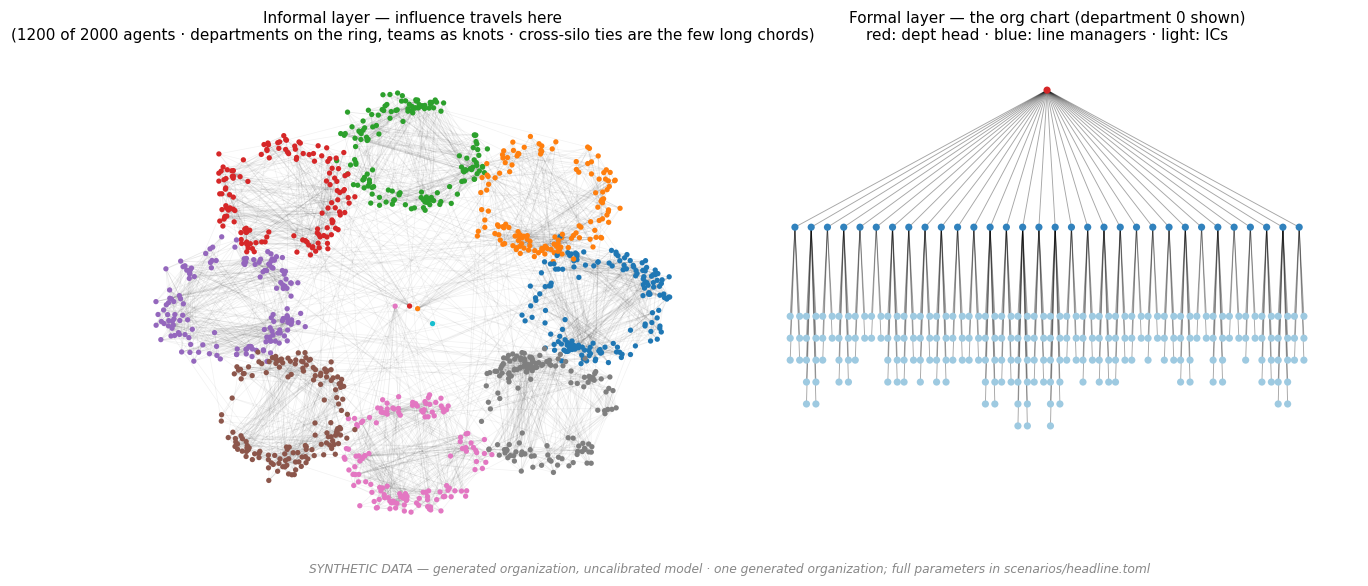

In [2]:
org = generate_org(**org_kwargs(SC), seed=R["master_seed"])
c = org.compile()
deg = c.degrees()
print(f"{c.n} agents · {org.informal.number_of_edges()} informal ties · "
      f"mean informal degree {deg.mean():.1f} (max {deg.max()}) · {c.n_teams - 1} line teams")

rng_viz = np.random.default_rng(0)
sample = rng_viz.choice(c.n, 1200, replace=False)
sub = org.informal.subgraph(sample.tolist())

# Structural layout (no scipy): departments on a ring, teams on sub-rings.
# Cross-department ties are then visibly rare — the silo geometry itself.
def org_layout(compiled, nodes, rng):
    D = compiled.dept.max() + 1
    pos = {}
    team_angle = {}
    for n in nodes:
        d, t = int(compiled.dept[n]), int(compiled.team[n])
        if d < 0 or t == 0:   # CEO + leadership team in the center
            pos[n] = (rng.normal(0, 0.05), rng.normal(0, 0.05))
            continue
        if t not in team_angle:
            team_angle[t] = rng.uniform(0, 2 * np.pi)
        a_d = 2 * np.pi * d / D
        cx, cy = np.cos(a_d), np.sin(a_d)
        a_t = team_angle[t]
        tx, ty = cx + 0.33 * np.cos(a_t), cy + 0.33 * np.sin(a_t)
        pos[n] = (tx + rng.normal(0, 0.045), ty + rng.normal(0, 0.045))
    return pos

pos = org_layout(c, list(sub.nodes()), np.random.default_rng(3))
fig, axes = plotting.fig_with_stamp(1, 2, figsize=(11.5, 5.2),
    note="one generated organization; full parameters in scenarios/headline.toml")
ax = axes[0]
nx.draw_networkx_edges(sub, pos, ax=ax, alpha=0.05, width=0.5)
nx.draw_networkx_nodes(sub, pos, ax=ax, node_size=12, linewidths=0, cmap="tab10",
                       node_color=[c.dept[n] % 10 for n in sub.nodes()])
ax.set_title(f"Informal layer — influence travels here\n({len(sub)} of {c.n} agents · departments on the ring, "
             "teams as knots · cross-silo ties are the few long chords)", fontsize=10)
ax.axis("off")

ax = axes[1]
d0 = [n for n in org.formal.nodes() if c.dept[n] == 0]
teams0 = sorted({int(c.team[n]) for n in d0 if c.team[n] != 0})
pos_f, head = {}, 1
pos_f[head] = (0.5, 2.2)
for x, t in zip(np.linspace(0.02, 0.98, len(teams0)), teams0):
    members = [n for n in d0 if c.team[n] == t]
    mgr = next(n for n in members if c.role[n] == defaults.ROLE_MANAGER)
    pos_f[mgr] = (x, 1.2)
    ics = [n for n in members if n != mgr]
    for i, ic in enumerate(ics):
        pos_f[ic] = (x + (i % 2 - 0.5) * 0.018, 0.55 - 0.16 * (i // 2))
sub_f = org.formal.subgraph(list(pos_f))
role_color = {0: "#9ecae1", 1: "#3182bd", 2: "#d62728"}
nx.draw_networkx_edges(sub_f, pos_f, ax=ax, alpha=0.35, width=0.6)
nx.draw_networkx_nodes(sub_f, pos_f, ax=ax, node_size=22, linewidths=0,
                       node_color=[role_color[int(c.role[n])] for n in sub_f.nodes()])
ax.set_title("Formal layer — the org chart (department 0 shown)\nred: dept head · blue: line managers · light: ICs", fontsize=10)
ax.axis("off"); ax.set_ylim(-1.2, 2.5)
plt.show()

## 2. The contagion and the five strategies

Each agent adopts when **all three** hold (spec §2.2; D4–D6):

| condition | meaning | operationalization |
|---|---|---|
| **ready** | enough credible exposure | weighted share of adopted contacts ≥ θᵢ, and share > 0 (awareness) |
| **willing** | individual disposition | Bernoulli(0.85) drawn once — a hard **85% ceiling** on any outcome here |
| **able** | practical capacity | per-department rate; 1.0 everywhere in this scenario (no planted handicaps, D6) |

Thresholds: θᵢ ~ Beta(mean **0.30**, concentration **20**), with a **2.5% innovator atom**
at θ = 0 (D1, D2). Updates are synchronous; decay is OFF until section 6 (D7).

One fixed budget — **5% of the organization** — for every seeded strategy (D9):

- **broadcast** — *zero* seeds; one step of universal awareness through the
  low-credibility comms channel (weight 0.3) — the reference floor (D8);
- **random** — 100 scattered volunteers;
- **champions** — the 100 best-connected agents (informal degree);
- **cluster** — whole teams, one after another (~12 pilot teams);
- **line-manager-first** — 100 random line managers.

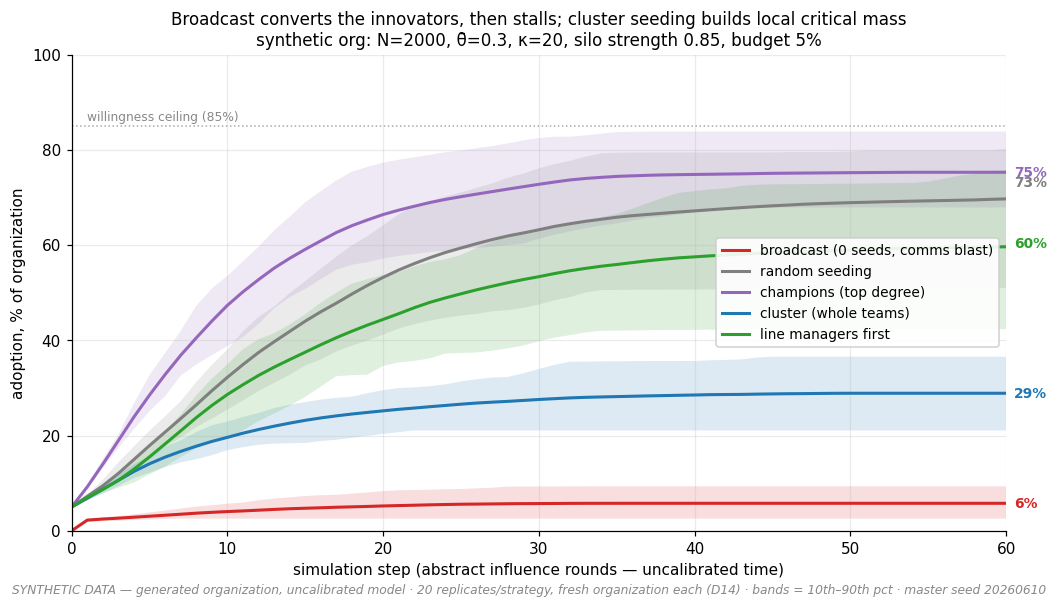

headline figure saved to docs/figures/headline.png · elapsed 4s


In [3]:
rows = exp1.run_strategy_comparison(SC)   # ~100 simulations, runs in parallel
curves = exp1.curves_by(rows)
reps = R["replicates"]

fig, ax = plotting.fig_with_stamp(figsize=(9.5, 5.4),
    note=f"{reps} replicates/strategy, fresh organization each (D14) · bands = 10th–90th pct · master seed {R['master_seed']}")
for strat in exp1.STRATEGY_ORDER:
    mean, lo, hi = exp1.band(curves[strat])
    plotting.plot_curve_band(ax, mean, lo, hi, plotting.STRATEGY_LABELS[strat],
                             plotting.STRATEGY_COLORS[strat])
    ax.annotate(f"{mean[-1]*100:.0f}%", xy=(60, mean[-1]*100), xytext=(5, 0),
                textcoords="offset points", fontsize=9, fontweight="bold",
                color=plotting.STRATEGY_COLORS[strat], va="center")
ax.axhline(85, color="#aaaaaa", linestyle=":", linewidth=1)
ax.text(1, 86.2, "willingness ceiling (85%)", fontsize=8, color="#888888")
ax.set_xlim(0, 60); ax.set_ylim(0, 100)
ax.set_xlabel("simulation step (abstract influence rounds — uncalibrated time)")
ax.set_ylabel("adoption, % of organization")
ax.set_title("Broadcast converts the innovators, then stalls; cluster seeding builds local critical mass\n"
             f"synthetic org: N={O['n_agents']}, θ̄={A['theta_mean']}, κ={A['theta_concentration']:.0f}, "
             f"silo strength {O['silo_strength']}, budget 5%", fontsize=11)
ax.legend(loc="center right", fontsize=9, framealpha=0.9)
out = plotting.save_fig(fig, REPO / "docs" / "figures" / "headline.png")
plt.show()
print(f"headline figure saved to {out.relative_to(REPO)} · elapsed {time.time()-T0:.0f}s")

### Reading the headline — including the part that disagrees with the folklore

**Broadcast (red) vs cluster (blue) — the spec's question.** Broadcast reaches everyone
once at credibility 0.3: that converts the ~2.5% zero-threshold innovators and almost
nobody else — scattered individuals who cannot push anyone over a 30% threshold. It
plateaus around **6%** (range 2–13%). Cluster seeding spends the same-sized budget
saturating ~12 whole teams: every neighbor of a pilot team sees *several* adopters at
once (wide sister-team bridges, D15), local cascades complete, and adoption reaches
**~29%** before the silos cap it. The two distributions do not overlap across 20
replicates (broadcast max 13% < cluster min 18.5%).

**The negative result (committed in D16 — not hidden).** *Scattered* strategies beat
cluster seeding here: random ≈ 73%, champions ≈ 75%. Why: in an organization of dense
small teams, **every random seed is already embedded in a cluster** — its own team —
and the heterogeneous threshold tail (plus the innovator atom) gives each seeded team
a ~30–40% chance of igniting locally. One hundred lottery tickets beat twelve
guaranteed wins. The popular heuristic "always seed clusters, never scatter" is **not
reproduced** by this model family; what survives is the weaker, more precise claim:
*concentrate enough local mass to cross thresholds — broadcast alone provides none*.
(Section 6 adds the second half of the story: under usage decay, scattering's lead
collapses while cluster's gains are locked in.)

In [4]:
table = exp1.summary_table(rows)
n = O["n_agents"]
print(f"{'strategy':<20}{'final mean±sd':>16}{'min…max':>16}{'never-ready share':>20}")
for t in table:
    print(f"{t['strategy']:<20}{t['final_mean']:>9.1%} ±{t['final_sd']:.1%}"
          f"{t['final_min']:>8.1%}…{t['final_max']:.1%}{t['mean_not_ready_share']:>16.1%}")
print("\n'never-ready share': agents who stayed below threshold to the end —")
print("the structural failure mass that more comms volume cannot reach (D4).")

strategy               final mean±sd         min…max   never-ready share
broadcast                5.8% ±3.3%    2.4%…13.0%           79.3%
random                  73.2% ±8.8%   51.0%…83.5%           12.6%
champions               75.3% ±7.0%   60.4%…86.3%           10.8%
cluster                 28.9% ±7.1%   18.5%…48.5%           56.8%
line_manager_first      60.3% ±12.9%   32.8%…84.3%           25.3%

'never-ready share': agents who stayed below threshold to the end —
the structural failure mass that more comms volume cannot reach (D4).


## 3. Where adoption dies: the dead-pocket map

Per-department final adoption (mean over replicates). A **dead pocket** is a unit under
25% critical mass (**D11**) — the diagnostic version of "the rollout never landed in
Operations". Broadcast leaves *every* department dead; cluster seeding produces a
sharp geography: pilot departments live, unreached silos stay dark.

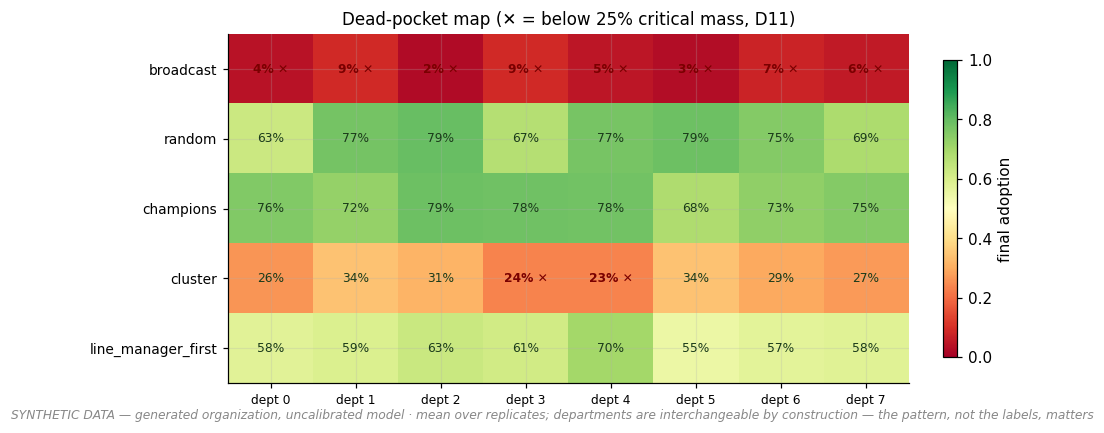

In [5]:
dmeans = exp1.dept_rate_means(rows)
mat = np.array([dmeans[s] for s in exp1.STRATEGY_ORDER])
fig, ax = plotting.fig_with_stamp(figsize=(8.5, 3.8),
    note="mean over replicates; departments are interchangeable by construction — the pattern, not the labels, matters")
im = ax.imshow(mat, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(mat.shape[1]), [f"dept {d}" for d in range(mat.shape[1])], fontsize=8)
ax.set_yticks(range(len(exp1.STRATEGY_ORDER)), exp1.STRATEGY_ORDER, fontsize=9)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        dead = mat[i, j] < defaults.ANALYSIS["dead_pocket_cutoff"]
        ax.text(j, i, f"{mat[i,j]*100:.0f}%" + (" ✕" if dead else ""),
                ha="center", va="center", fontsize=8,
                color="#7a0000" if dead else "#1a3a1a",
                fontweight="bold" if dead else "normal")
fig.colorbar(im, ax=ax, label="final adoption", shrink=0.85)
ax.set_title(f"Dead-pocket map (✕ = below {defaults.ANALYSIS['dead_pocket_cutoff']:.0%} critical mass, D11)", fontsize=11)
plt.show()

## 4. Why the non-adopters didn't adopt

The ready/willing/able decomposition makes every non-adoption attributable to exactly
one missing gate (spec §2.2). With `able = 1.0` everywhere (D6) and willingness a flat
15% lottery (D5), all the *strategy-dependent* failure is concentrated in **never
ready**: people whose credible exposure simply never reached their threshold. That bar
is what a better seeding geometry buys down — and what more broadcast volume cannot.

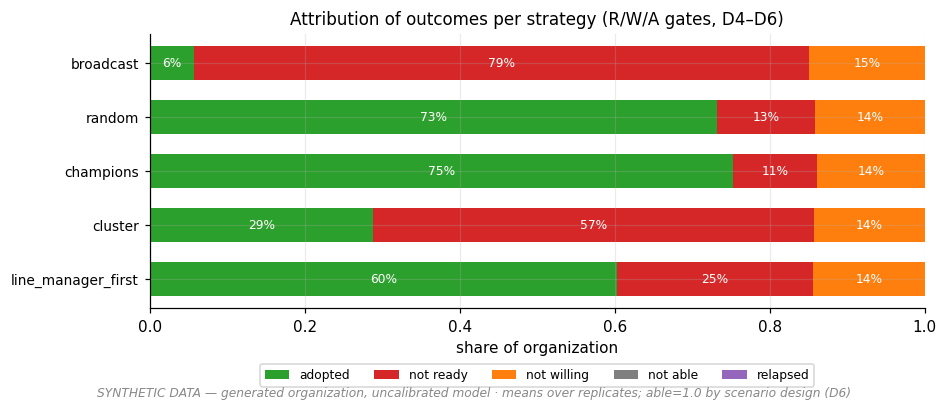

In [6]:
cats = [("adopted", "#2ca02c"), ("not_ready", "#d62728"),
        ("not_willing", "#ff7f0e"), ("not_able", "#7f7f7f"), ("relapsed", "#9467bd")]
n = O["n_agents"]
shares = {s: [np.mean([r[f"n_{k}"] for r in rows if r["strategy"] == s]) / n
              for k, _ in cats] for s in exp1.STRATEGY_ORDER}
fig, ax = plotting.fig_with_stamp(figsize=(8.5, 3.6), note="means over replicates; able=1.0 by scenario design (D6)")
left = np.zeros(len(exp1.STRATEGY_ORDER))
ys = np.arange(len(exp1.STRATEGY_ORDER))
for ci, (k, color) in enumerate(cats):
    vals = np.array([shares[s][ci] for s in exp1.STRATEGY_ORDER])
    ax.barh(ys, vals, left=left, color=color, label=k.replace("_", " "), height=0.62)
    for y, v, l in zip(ys, vals, left):
        if v > 0.04:
            ax.text(l + v / 2, y, f"{v*100:.0f}%", ha="center", va="center", fontsize=8, color="white")
    left += vals
ax.set_yticks(ys, exp1.STRATEGY_ORDER, fontsize=9)
ax.invert_yaxis(); ax.set_xlim(0, 1)
ax.set_xlabel("share of organization")
ax.set_title("Attribution of outcomes per strategy (R/W/A gates, D4–D6)", fontsize=11)
ax.legend(ncols=5, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.show()

## 5. Silos gate the spread

Same scenario, sweeping `silo_strength` (cross-department tie scarcity). Broadcast is
flat — it fails for threshold reasons, not structural ones. Cluster seeding is capped
by the silos: its cascades saturate the departments they start in and need
cross-department bridges to jump. Random seeding degrades more gently — scattering
buys silo *insurance* (seeds land everywhere), another piece of the honest trade-off.

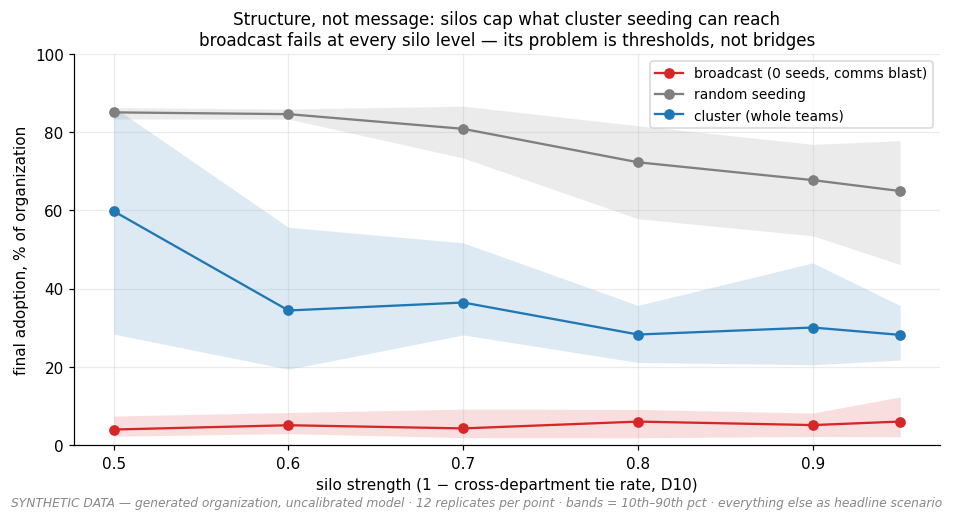

elapsed 9s


In [7]:
silo_rows = exp1.run_silo_panel(SC)   # ~216 simulations
finals = exp1.finals_by(silo_rows, "seeding.strategy", "org.silo_strength")
fig, ax = plotting.fig_with_stamp(figsize=(8.5, 4.6),
    note=f"12 replicates per point · bands = 10th–90th pct · everything else as headline scenario")
for strat in ("broadcast", "random", "cluster"):
    m = [np.mean(finals[(strat, s)]) * 100 for s in exp1.SILO_AXIS]
    lo = [np.percentile(finals[(strat, s)], 10) * 100 for s in exp1.SILO_AXIS]
    hi = [np.percentile(finals[(strat, s)], 90) * 100 for s in exp1.SILO_AXIS]
    color = plotting.STRATEGY_COLORS[strat]
    ax.plot(exp1.SILO_AXIS, m, "o-", color=color, label=plotting.STRATEGY_LABELS[strat])
    ax.fill_between(exp1.SILO_AXIS, lo, hi, color=color, alpha=0.15, linewidth=0)
ax.set_xlabel("silo strength (1 − cross-department tie rate, D10)")
ax.set_ylabel("final adoption, % of organization")
ax.set_ylim(0, 100)
ax.set_title("Structure, not message: silos cap what cluster seeding can reach\n"
             "broadcast fails at every silo level — its problem is thresholds, not bridges", fontsize=11)
ax.legend(fontsize=9)
plt.show()
print(f"elapsed {time.time()-T0:.0f}s")

## 6. Decay: what survives when usage needs reinforcement

Switch on de-adoption (**D7**): every step, an adopter whose credible-adopter share sits
below their own threshold quits with probability 0.25. Two findings, both reported as
measured (D7 amendment in `docs/decisions.md`):

1. **No "spike then relapse".** The documented rollout pattern — usage peaks, then
   sags — does *not* emerge from reinforcement-based decay: relapse and adoption
   interleave, so decay shows up as a lower plateau, never an overshoot. Reproducing
   the overshoot would need *non-social* novelty decay, which we declined to bolt on
   (it would be curve-fitting, D7 option 2). **A real limitation, stated plainly.**
2. **Decay inverts part of the ranking.** Scattered adoption is fragile — random's
   plateau collapses from ~73% to ~26% — while cluster-seeded adoption barely moves
   (~29% → ~32%): everyone a pilot team converted is *surrounded* by other adopters.
   Local critical mass is not just how you cross thresholds; it is how adoption
   **stays** adopted.

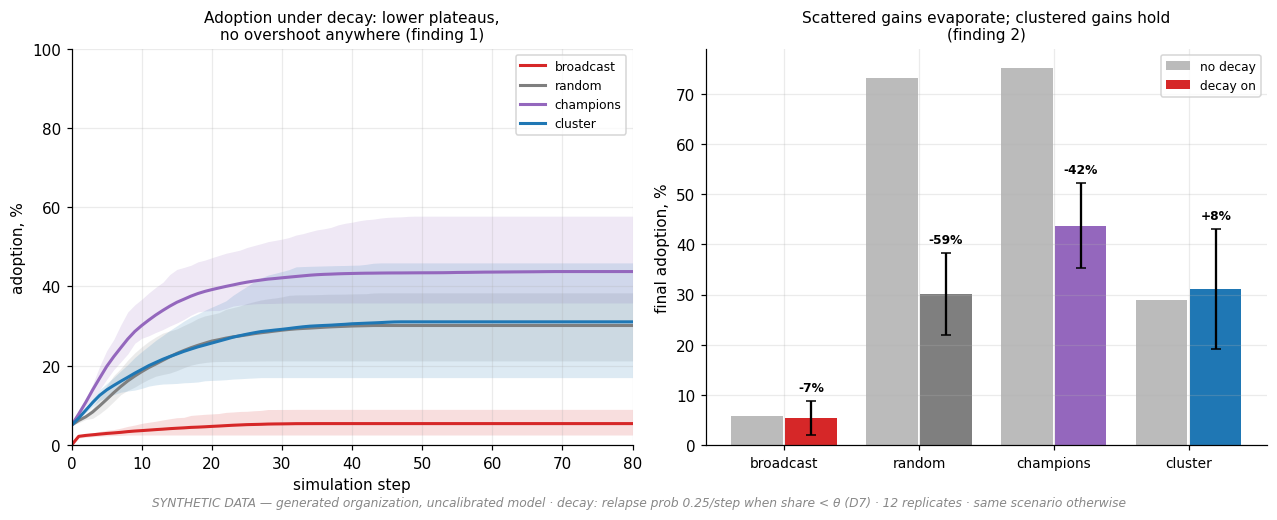

In [8]:
decay_rows = exp1.run_decay_demo(SC)    # relapse_prob 0.25, retention_factor 1.0
strategies = ["broadcast", "random", "champions", "cluster"]
no_decay = {s: np.mean([r["final_rate"] for r in rows if r["strategy"] == s]) for s in strategies}
with_decay = {s: np.mean([r["final_rate"] for r in decay_rows if r["strategy"] == s]) for s in strategies}
sd_decay = {s: np.std([r["final_rate"] for r in decay_rows if r["strategy"] == s]) for s in strategies}

fig, axes = plotting.fig_with_stamp(1, 2, figsize=(11.5, 4.6),
    note="decay: relapse prob 0.25/step when share < θ (D7) · 12 replicates · same scenario otherwise")
ax = axes[0]
dcurves = exp1.curves_by(decay_rows)
for s in strategies:
    mean, lo, hi = exp1.band(dcurves[s])
    plotting.plot_curve_band(ax, mean, lo, hi, s, plotting.STRATEGY_COLORS[s])
ax.set_xlim(0, 80); ax.set_ylim(0, 100)
ax.set_xlabel("simulation step"); ax.set_ylabel("adoption, %")
ax.set_title("Adoption under decay: lower plateaus,\nno overshoot anywhere (finding 1)", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
x = np.arange(len(strategies))
ax.bar(x - 0.2, [no_decay[s] * 100 for s in strategies], width=0.38, label="no decay", color="#bbbbbb")
ax.bar(x + 0.2, [with_decay[s] * 100 for s in strategies], width=0.38, label="decay on",
       color=[plotting.STRATEGY_COLORS[s] for s in strategies],
       yerr=[sd_decay[s] * 100 for s in strategies], capsize=3)
for xi, s in zip(x, strategies):
    drop = (with_decay[s] - no_decay[s]) / max(no_decay[s], 1e-9)
    ax.text(xi + 0.2, with_decay[s] * 100 + sd_decay[s] * 100 + 2, f"{drop:+.0%}",
            ha="center", fontsize=8, fontweight="bold")
ax.set_xticks(x, strategies, fontsize=9)
ax.set_ylabel("final adoption, %")
ax.set_title("Scattered gains evaporate; clustered gains hold\n(finding 2)", fontsize=10)
ax.legend(fontsize=8)
plt.show()

## 7. Relays: is any single person load-bearing? (a null result, plus a positive control)

**Pivot nodes** (**D12**) are found by counterfactual knockout: remove one node, re-run
the cluster-seeded scenario for the *same workforce*, measure the plateau shift.

Two things below, both honest:

- **Left — the null result.** On generated organizations, knocking out any of the
  top-12 betweenness nodes (which includes the CEO and department heads) moves the
  plateau by ≈ 0: redundant bridges mean **no individual is load-bearing**. We probed
  harsher variants too — hermetic silos, one-sided single-department pilots — and
  either the cascade never jumps at all (the receiving side would need a
  zero-threshold person *on the bridge*) or it jumps through redundant paths. We do
  not fish for lucky seeds to manufacture a hero-relay demo (D12 amendment).
- **Right — the positive control.** On a designed bottleneck (two 5-person cliques
  joined by a single relay) the same diagnostic finds the relay immediately, with a
  ~45 pp knockout effect. The tool works; *this generator's organizations simply
  don't produce single points of failure* — imported real topologies with genuine
  bottlenecks are where this diagnostic earns its keep.

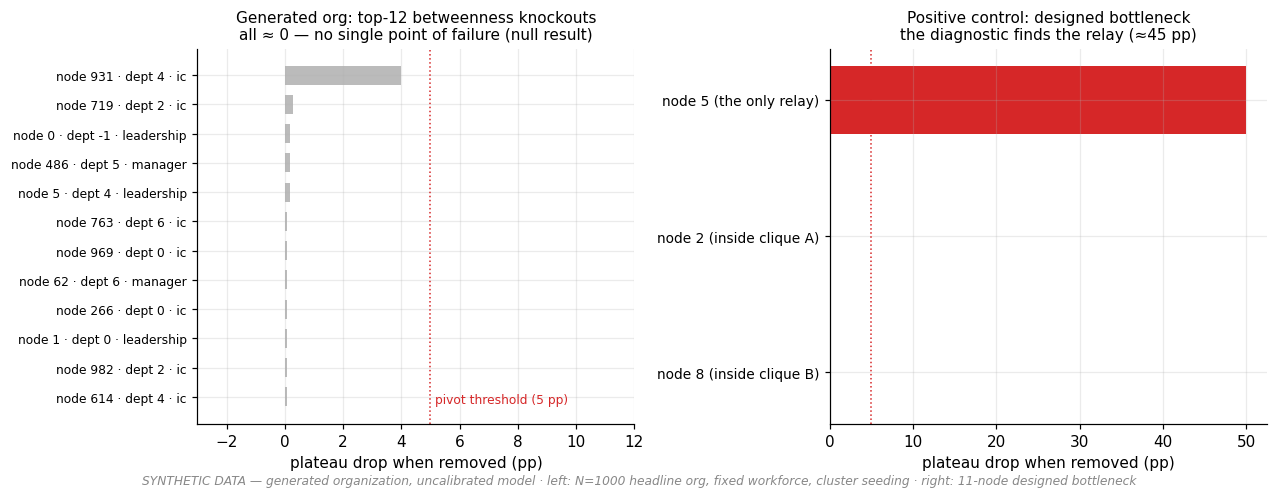

max knockout effect in generated org: 4.0 pp · relay knockout in barbell: 50 pp · elapsed 14s


In [9]:
from core.dynamics import SimParams, draw_agents
from core.seeding import Seeding

# Left: knockouts at headline parameters (N=1000), fixed workforce.
sc_p = set_path(set_path(SC, "org.n_agents", 1000), "org.silo_strength", 0.8)
org_p = generate_org(**org_kwargs(sc_p), seed=11)
cp = org_p.compile()
params_p = build_sim_params(sc_p)
agents_p = draw_agents(cp, params_p, np.random.default_rng(99))
cands = metrics.betweenness_candidates(org_p, top_m=12)
reports = metrics.pivot_nodes(
    cp, params_p, lambda cc, rng: make_seeding("cluster", cc, 0.05, rng),
    cands, reps=1, rng_seed=5, agents=agents_p,
)

# Right: positive control — a designed bottleneck the diagnostic must find.
import networkx as nx_
gb = nx_.Graph()
for grp, nodes in (("A", range(5)), ("B", range(6, 11))):
    for i in nodes:
        for j in nodes:
            if i < j: gb.add_edge(i, j, weight=1.0)
gb.add_edge(0, 5, weight=1.0); gb.add_edge(1, 5, weight=1.0)
gb.add_edge(5, 6, weight=1.0); gb.add_edge(5, 7, weight=1.0)
for n in gb.nodes():
    gb.add_node(n, team=0 if n <= 5 else 1, dept=0 if n <= 5 else 1, role=0, tenure=5.0)
from core.orggen import OrgGraph
cb = OrgGraph(formal=gb, informal=gb, params={"kind": "test"}).compile()
params_b = SimParams(theta_mean=0.2, theta_concentration=10000, p_innovator=0.0,
                     p_willing=(1.0, 1.0, 1.0), max_steps=30)
rep_b = metrics.pivot_nodes(
    cb, params_b, lambda cc, rng: Seeding("random", np.array([0, 1]), False, {}),
    candidates=[5, 2, 8], reps=1, rng_seed=1,
)

fig, axes = plotting.fig_with_stamp(1, 2, figsize=(11.5, 4.4),
    note="left: N=1000 headline org, fixed workforce, cluster seeding · right: 11-node designed bottleneck")
ax = axes[0]
labels = [f"node {r.node} · dept {cp.dept[r.node]} · {defaults.ROLE_NAMES[int(cp.role[r.node])]}" for r in reports]
ax.barh(np.arange(len(reports)), [r.delta_plateau * 100 for r in reports], color="#bbbbbb", height=0.65)
ax.set_yticks(np.arange(len(reports)), labels, fontsize=8)
ax.invert_yaxis()
ax.axvline(5, color="#d62728", linestyle=":", linewidth=1)
ax.text(5.15, len(reports) - 0.8, "pivot threshold (5 pp)", fontsize=8, color="#d62728")
ax.set_xlim(-3, 12)
ax.set_xlabel("plateau drop when removed (pp)")
ax.set_title(f"Generated org: top-12 betweenness knockouts\nall ≈ 0 — no single point of failure (null result)", fontsize=10)

ax = axes[1]
lbl = {5: "node 5 (the only relay)", 2: "node 2 (inside clique A)", 8: "node 8 (inside clique B)"}
colors = ["#d62728" if r.is_pivot else "#bbbbbb" for r in rep_b]
ax.barh(np.arange(len(rep_b)), [r.delta_plateau * 100 for r in rep_b], color=colors, height=0.5)
ax.set_yticks(np.arange(len(rep_b)), [lbl[r.node] for r in rep_b], fontsize=9)
ax.invert_yaxis()
ax.axvline(5, color="#d62728", linestyle=":", linewidth=1)
ax.set_xlabel("plateau drop when removed (pp)")
ax.set_title("Positive control: designed bottleneck\nthe diagnostic finds the relay (≈45 pp)", fontsize=10)
plt.show()
print(f"max knockout effect in generated org: {max(r.delta_plateau for r in reports)*100:.1f} pp · "
      f"relay knockout in barbell: {rep_b[0].delta_plateau*100:.0f} pp · elapsed {time.time()-T0:.0f}s")

## 8. What you may conclude — and what you may not

**Within this synthetic model family (and nowhere else), the experiment supports:**

1. One-shot broadcast cannot start a complex contagion: it converts the
   zero-threshold innovators (~2.5%) and stalls. Its failure is threshold-driven and
   silo-independent.
2. Equal-budget cluster seeding reliably builds local critical mass and reaches a
   plateau capped by silo strength — the structure decides its ceiling.
3. **Negative result:** scattered strategies (random, champions) beat cluster seeding
   on raw reach here, because dense small teams make every scattered seed a latent
   cluster seed. The folklore "always seed clusters" is not reproduced.
4. Under reinforcement-dependent decay the trade reverses: scattered gains collapse,
   clustered gains hold. Reach favors scattering; retention favors clustering.
5. **Third negative result:** no pivot nodes exist in generated organizations —
   redundant bridges mean no individual is load-bearing, and betweenness celebrities
   (CEO, heads) least of all. The knockout diagnostic is validated on a designed
   bottleneck and reserved for real topologies (D12 amendment).
6. **Second negative result:** the documented "spike then relapse" pattern does not
   emerge from socially-reinforced decay (D7 amendment).

**You may not conclude:** anything about any real organization (no calibration — see
[`docs/limitations.md`](../docs/limitations.md), all twelve entries); anything about
durations (steps are uncalibrated); anything about strategies not modeled (hybrids,
sequenced campaigns); that these orderings survive different threshold distributions —
that sensitivity lives in notebook 02.

**Provenance.** Scenario `headline.toml` (D16) · all modeling decisions PROVISIONAL in
[`docs/decisions.md`](../docs/decisions.md) · results + metadata under
`experiments/results/` · total notebook runtime printed below.

In [10]:
print(f"total runtime: {time.time()-T0:.0f}s")
print("results written:", *(p.name for p in sorted((REPO / 'experiments' / 'results').glob('exp1_*headline*'))), sep="\n  ")

total runtime: 14s
results written:
  exp1_decay_headline.csv
  exp1_decay_headline.meta.json
  exp1_silo_headline.csv
  exp1_silo_headline.meta.json
  exp1_strategies_headline.csv
  exp1_strategies_headline.meta.json
